In [1]:
# Cell 1: Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Cell 2: 
base_path = '/kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)'
drowsy_path = os.path.join(base_path, 'Drowsy')
nondrowsy_path = os.path.join(base_path, 'Non Drowsy')

print(f"Base path: {base_path}")
print(f"Drowsy path: {drowsy_path}")
print(f"Non-Drowsy path: {nondrowsy_path}")

assert os.path.exists(base_path), f"Base path not exist: {base_path}"
assert os.path.exists(drowsy_path), f"Drowsy path not exist: {drowsy_path}"
assert os.path.exists(nondrowsy_path), f"Non-Drowsy path not exist: {nondrowsy_path}"

# Get file lists
drowsy_files = sorted([os.path.join(drowsy_path, f) for f in os.listdir(drowsy_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
nondrowsy_files = sorted([os.path.join(nondrowsy_path, f) for f in os.listdir(nondrowsy_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print(f'✅ Drowsy: {len(drowsy_files):,} images')
print(f'✅ Non-Drowsy: {len(nondrowsy_files):,} images')
print(f"first 3 files Drowsy: {drowsy_files[:3]}")

Base path: /kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)
Drowsy path: /kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)/Drowsy
Non-Drowsy path: /kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)/Non Drowsy
✅ Drowsy: 22,348 images
✅ Non-Drowsy: 19,445 images
أول 3 ملفات Drowsy: ['/kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0001.png', '/kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0002.png', '/kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0003.png']


In [3]:
# Cell 3: Create Sequences + Dataset
SEQ_LEN = 16  # 16 frame for each sequence
IMG_SIZE = 224
BATCH_SIZE = 16

def create_sequences(file_list, label):
    sequences = []
    labels_seq = []
    for i in range(0, len(file_list) - SEQ_LEN, 8):  # step=8
        seq = file_list[i:i+SEQ_LEN]
        if len(seq) == SEQ_LEN: 
            sequences.append(seq)
            labels_seq.append(label)
    return sequences, labels_seq

# creating sequences
drowsy_seq, drowsy_labels = create_sequences(drowsy_files, 1)   # 1 = Drowsy
nondrowsy_seq, nondrowsy_labels = create_sequences(nondrowsy_files, 0)  # 0 = Non-Drowsy

all_sequences = drowsy_seq + nondrowsy_seq
all_labels = drowsy_labels + nondrowsy_labels

print(f"✅ Drowsy sequences: {len(drowsy_seq)}")
print(f"✅ Non-Drowsy sequences: {len(nondrowsy_seq)}")
print(f"Total sequences: {len(all_sequences)}")

✅ Drowsy sequences: 2792
✅ Non-Drowsy sequences: 2429
Total sequences: 5221


In [4]:
# Cell 4: DataLoader
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class DrowsinessDataset(Dataset):
    def __init__(self, sequences, labels, transform=None):
        self.sequences = sequences
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq_files = self.sequences[idx]
        seq_images = []
        
        for img_path in seq_files:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            seq_images.append(image)
        
        seq_tensor = torch.stack(seq_images)  # [16, 3, 224, 224]
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return seq_tensor.permute(1, 0, 2, 3), label  # [3, 16, 224, 224]

# Split
train_seq, test_seq, train_lbl, test_lbl = train_test_split(
    all_sequences, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

train_dataset = DrowsinessDataset(train_seq, train_lbl, transform)
test_dataset = DrowsinessDataset(test_seq, test_lbl, transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

✅ Train batches: 261, Test batches: 66


In [5]:
# Cell 5: Hybrid CNN-LSTM Model
import torch.nn as nn

class CNNLSTMHybrid(nn.Module):
    def __init__(self, num_classes=2):
        super(CNNLSTMHybrid, self).__init__()
        
        # CNN Feature Extractor - 4 
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # Layer 1
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # Layer 2
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # Layer 3
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU()                  # Layer 4
        )
        
        # LSTM - 2 bidirectional
        self.lstm = nn.LSTM(256, 128, num_layers=2, batch_first=True, 
                           bidirectional=True, dropout=0.3)
        
        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(256, 128),  # 128*2=256
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        batch_size, C, seq_len, H, W = x.shape  # [batch, 3, 16, 224, 224]
        
        # CNN for every frame
        cnn_features = []
        for t in range(seq_len):
            frame = x[:, :, t, :, :]
            feat = self.cnn(frame)
            feat = torch.mean(feat, dim=[2, 3])  # [batch, 256]
            cnn_features.append(feat)
        
        lstm_input = torch.stack(cnn_features, dim=1)  # [batch, 16, 256]
        lstm_out, _ = self.lstm(lstm_input)
        output = self.fc(lstm_out[:, -1, :])  # last timestep
        
        return output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNLSTMHybrid().to(device)
print(f"✅ Model loaded on {device}")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

✅ Model loaded on cuda
Total params: 1,212,098


In [6]:
# Cell 6: Training Loop
def train_model(model, train_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    best_acc = 0
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        correct_train, total_train = 0, 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            pred = output.argmax(1)
            correct_train += pred.eq(target).sum().item()
            total_train += target.size(0)
            
            pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'Acc': f'{100.*pred.eq(target).sum().item()/target.size(0):.1f}%'})
        
        # Test
        model.eval()
        test_loss = 0
        correct_test, total_test = 0, 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                test_loss += criterion(output, target).item()
                pred = output.argmax(1)
                correct_test += pred.eq(target).sum().item()
                total_test += target.size(0)
        
        # Metrics
        train_acc = 100. * correct_train / total_train
        test_acc = 100. * correct_test / total_test
        
        train_losses.append(train_loss/len(train_loader))
        test_losses.append(test_loss/len(test_loader))
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        scheduler.step()
        
        print(f'\nEpoch {epoch+1}: Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), 'best_cnn_lstm_model.pth')
    
    return train_losses, test_losses, train_accs, test_accs

# start training
history = train_model(model, train_loader, test_loader, epochs=10)
print("✅ Best model saved!.")

Epoch 1/10: 100%|██████████| 261/261 [07:49<00:00,  1.80s/it, Loss=0.6133, Acc=56.2%]



Epoch 1: Train Acc: 58.76%, Test Acc: 68.90%


Epoch 2/10: 100%|██████████| 261/261 [04:00<00:00,  1.08it/s, Loss=0.2702, Acc=93.8%] 



Epoch 2: Train Acc: 72.58%, Test Acc: 78.47%


Epoch 3/10: 100%|██████████| 261/261 [03:57<00:00,  1.10it/s, Loss=0.3906, Acc=75.0%] 


...


Epoch 8: Train Acc: 98.78%, Test Acc: 99.43%


Epoch 9/10: 100%|██████████| 261/261 [04:02<00:00,  1.07it/s, Loss=0.0036, Acc=100.0%]



Epoch 9: Train Acc: 98.01%, Test Acc: 98.85%


Epoch 10/10: 100%|██████████| 261/261 [03:53<00:00,  1.12it/s, Loss=0.0213, Acc=100.0%]



Epoch 10: Train Acc: 98.80%, Test Acc: 99.23%
✅ التدريب خلص! Best model saved.


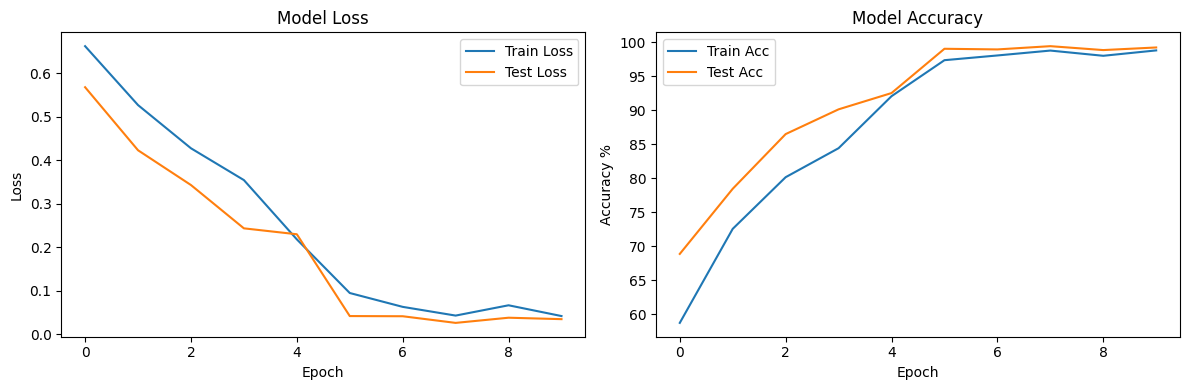

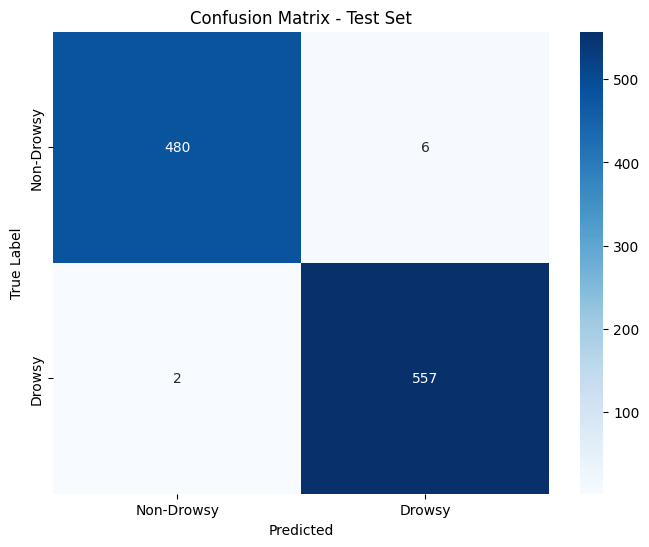

Classification Report:
              precision    recall  f1-score   support

  Non-Drowsy       1.00      0.99      0.99       486
      Drowsy       0.99      1.00      0.99       559

    accuracy                           0.99      1045
   macro avg       0.99      0.99      0.99      1045
weighted avg       0.99      0.99      0.99      1045

✅ Final Test Accuracy: 99.23%


In [8]:
# Cell 7: Results & Plots 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

train_losses, test_losses, train_accs, test_accs = history

# Loss & Accuracy curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.legend()

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix (test set)
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(1)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Drowsy', 'Drowsy'],
            yticklabels=['Non-Drowsy', 'Drowsy'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Classification Report:")
print(classification_report(all_targets, all_preds, 
                          target_names=['Non-Drowsy', 'Drowsy']))

final_accuracy = 100 * np.sum(all_preds == all_targets) / len(all_targets)
print(f"✅ Final Test Accuracy: {final_accuracy:.2f}%")

In [12]:
# Cell 8: Test Prediction 
from PIL import Image
import torch

def predict_single_sequence(model, seq_files):
    model.eval()
    seq_images = []
    
    # 16 images [3, 224, 224]
    for img_path in seq_files[:16]:
        image = Image.open(img_path).convert('RGB')
        image = transform(image)  # [3, 224, 224]
        seq_images.append(image)
    
    # Stack sequences → [16, 3, 224, 224]
    seq_tensor = torch.stack(seq_images)  # [16, 3, 224, 224]
    
    # Permute model input → [3, 16, 224, 224]  (batch_size=1)
    seq_tensor = seq_tensor.permute(1, 0, 2, 3).unsqueeze(0).to(device)  # [1, 3, 16, 224, 224]
    
    with torch.no_grad():
        output = model(seq_tensor)
        pred = output.argmax(1).item()
        prob = torch.softmax(output, dim=1).max().item()
    
    return 'Drowsy' if pred == 1 else 'Non-Drowsy', prob

# Test for first sequence
test_seq_sample = test_seq[0]
true_label = test_lbl[0]
label_name = 'Drowsy' if true_label == 1 else 'Non-Drowsy'
pred_name, confidence = predict_single_sequence(model, test_seq_sample)

print(f"True Label:     {label_name}")
print(f"Predicted:      {pred_name}")
print(f"Confidence:     {confidence:.3f}")
print("✅ Prediction successful!")

True Label:     Non-Drowsy
Predicted:      Non-Drowsy
Confidence:     0.998
✅ Prediction successful!
